### 📊 B3 Stock Analysis: PETR4 vs ITUB4

This project analyzes the historical prices of two major Brazilian stocks:

- PETR4 (Petrobras)
- ITUB4 (Itaú)

The goal is to:
- Visualize price evolution
- Analyze daily variations
- Understand distribution and volatility

In [1]:
!pip install yfinance

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 10.4 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15618 sha256=96b8e662cf729029499d46fe579494c52e73d82b66ef509a46ef90157d2f1e8d
  Stored in directory: c:\users\f4212\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ---------

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334


### 1. 📚 Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

### 2. 📥 Data Collection

We use the `yfinance` library to download stock data directly from Yahoo Finance.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
df = yf.download(['PETR4.SA', 'ITUB4.SA'],
                 start='2025-10-01',
                 end='2026-03-31')

df.head()

[*********************100%***********************]  2 of 2 completed


Price           Close                  High                   Low             \
Ticker       ITUB4.SA   PETR4.SA   ITUB4.SA   PETR4.SA   ITUB4.SA   PETR4.SA   
Date                                                                           
2025-10-01  34.841591  30.419300  35.804617  30.584096  34.796167  30.341749   
2025-10-02  34.460018  30.128485  35.159577  30.448382  34.423679  30.070322   
2025-10-03  34.714405  30.050934  34.714405  30.370831  34.269233  30.050934   
2025-10-06  34.314655  29.779505  34.750742  30.273891  34.314655  29.760118   
2025-10-07  33.769547  29.886139  34.278312  29.915221  33.587842  29.420835   

Price            Open               Volume            
Ticker       ITUB4.SA   PETR4.SA  ITUB4.SA  PETR4.SA  
Date                                                  
2025-10-01  35.668341  30.487159  25519177  24817000  
2025-10-02  34.905190  30.419299  17094601  25497100  
2025-10-03  34.441849  30.206035  17766985  19756800  
2025-10-06  34.705318  30.244811  14832309  21245400  
2025-10-07  34.269231  29.779506  20705472  29068800

### 3. 🔧 Data Preparation

We will extract:
- Dates
- Closing prices for each stock

In [7]:
dados = df['Close'].copy()

dados.reset_index(inplace=True)

dias = dados['Date']
petro = dados['PETR4.SA']
itau = dados['ITUB4.SA']

### 4. 📊 Data Visualization

We will create:
- A line chart (price over time)
- Two histograms (daily variation)

#### Stock Prices (Oct 2025 - Mar 2026)

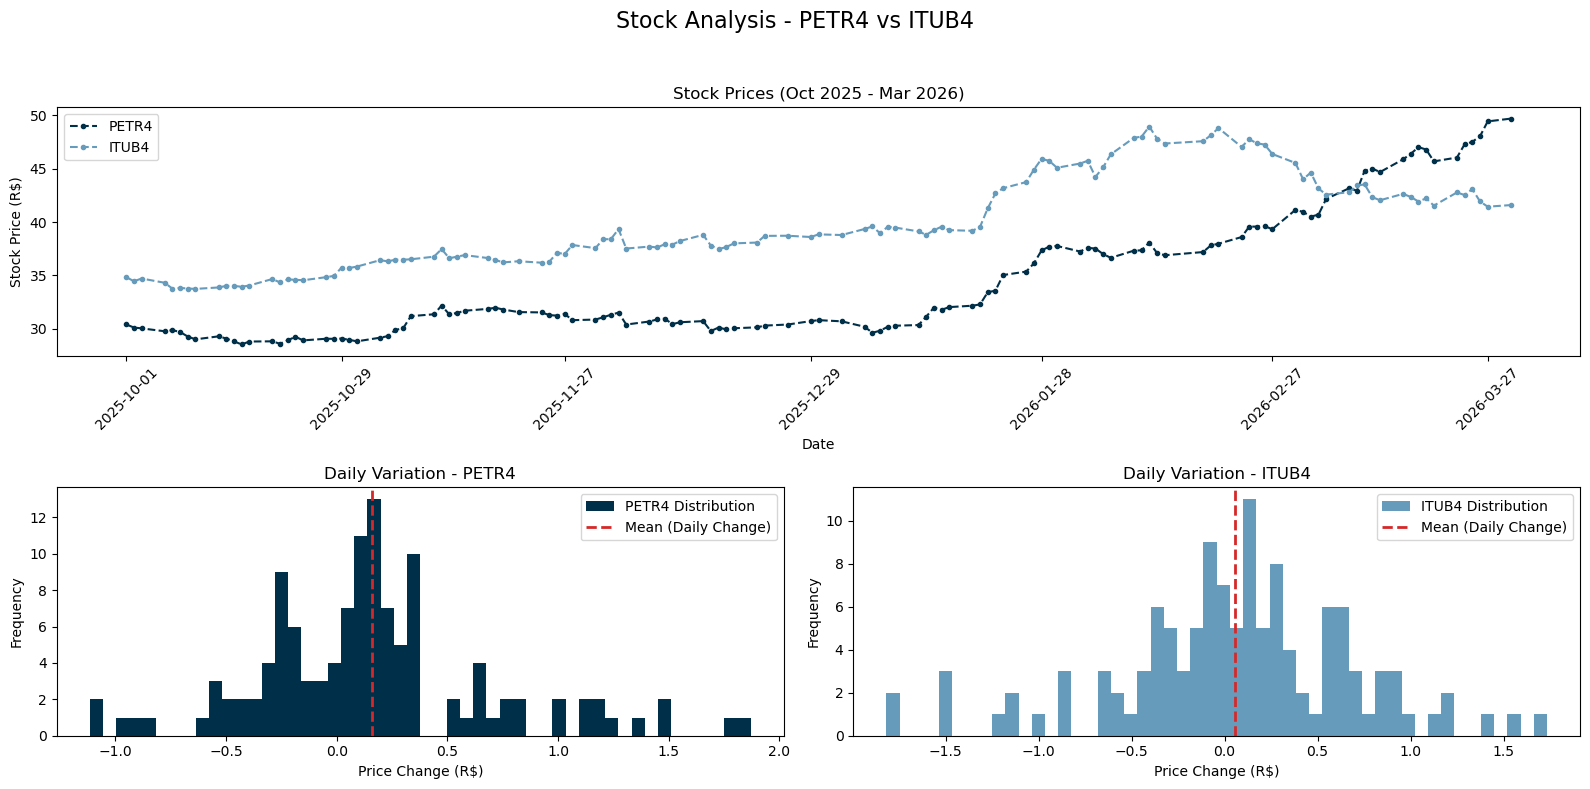

In [15]:
# Create figure
fig = plt.figure(figsize=(16, 8))

# Create grid layout
grid = fig.add_gridspec(2, 2)

# Subplots
ax_linha = fig.add_subplot(grid[0, :])
ax_hist_1 = fig.add_subplot(grid[1, 0])
ax_hist_2 = fig.add_subplot(grid[1, 1])

# ===============================
# 🔹 Line plot (price over time)
# ===============================
ax_linha.plot(dias, petro,
              color='#003049', linestyle='--', marker='.',
              label='PETR4')

ax_linha.plot(dias, itau,
              color='#669bbc', linestyle='--', marker='.',
              label='ITUB4')

ax_linha.set_title('Stock Prices (Oct 2025 - Mar 2026)')
ax_linha.set_xlabel('Date')
ax_linha.set_ylabel('Stock Price (R$)')

# Reduce number of ticks for readability
ax_linha.set_xticks(dias[::20])
ax_linha.tick_params(axis='x', rotation=45)

# Legend for line plot
ax_linha.legend()

# ===============================
# 🔹 Daily variation (difference)
# ===============================
petro_diff = petro.diff()
itau_diff = itau.diff()

# ===============================
# 🔹 Histogram PETR4
# ===============================
ax_hist_1.hist(petro_diff.dropna(),
               color='#003049',
               bins=50,
               label='PETR4 Distribution')

ax_hist_1.axvline(petro_diff.mean(),
                  color='#d62828',
                  linestyle='--',
                  linewidth=2,
                  label='Mean (Daily Change)')

ax_hist_1.set_title('Daily Variation - PETR4')
ax_hist_1.set_xlabel('Price Change (R$)')
ax_hist_1.set_ylabel('Frequency')

# Legend PETR4
ax_hist_1.legend()

# ===============================
# 🔹 Histogram ITUB4
# ===============================
ax_hist_2.hist(itau_diff.dropna(),
               color='#669bbc',
               bins=50,
               label='ITUB4 Distribution')

ax_hist_2.axvline(itau_diff.mean(),
                  color='#d62828',
                  linestyle='--',
                  linewidth=2,
                  label='Mean (Daily Change)')

ax_hist_2.set_title('Daily Variation - ITUB4')
ax_hist_2.set_xlabel('Price Change (R$)')
ax_hist_2.set_ylabel('Frequency')

# Legend ITUB4
ax_hist_2.legend()

# ===============================
# 🔹 Global settings
# ===============================
fig.suptitle('Stock Analysis - PETR4 vs ITUB4', fontsize=16)

# Adjust layout (important with suptitle)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save files
plt.savefig('stock_analysis.png')
plt.savefig('stock_analysis.pdf')
plt.savefig('stock_analysis.svg')

# Show
plt.show()

#### Stock Price Evolution: PETR4 vs ITUB4

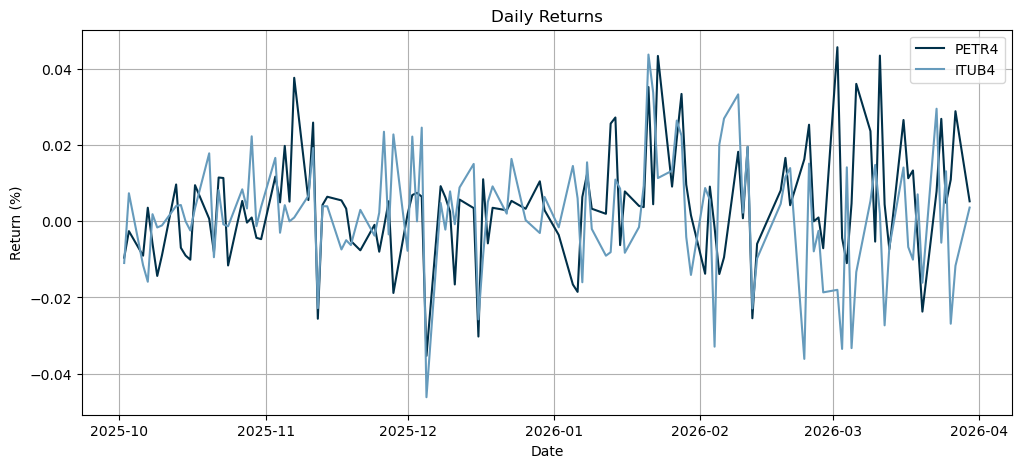

In [13]:
returns = dados[['PETR4.SA', 'ITUB4.SA']].pct_change()

plt.figure(figsize=(12, 5))

plt.plot(dias, returns['PETR4.SA'], color='#003049', label='PETR4')
plt.plot(dias, returns['ITUB4.SA'], color='#669bbc', label='ITUB4')

plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Return (%)')

plt.legend()
plt.grid(True)

plt.show()

#### Price Trend of PETR4 and ITUB4 (Oct 2025 – Mar 2026)

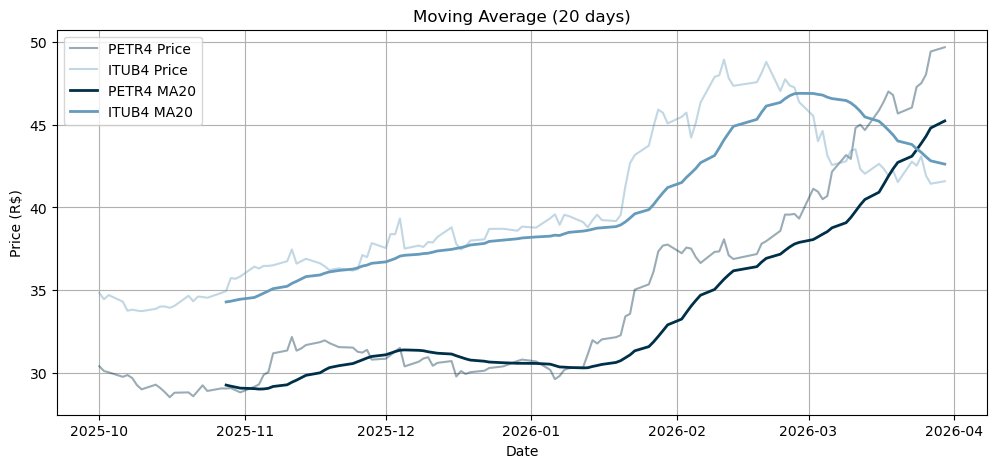

In [14]:
ma20_petro = petro.rolling(20).mean()
ma20_itau = itau.rolling(20).mean()

plt.figure(figsize=(12, 5))

# Preço
plt.plot(dias, petro, color='#003049', alpha=0.4, label='PETR4 Price')
plt.plot(dias, itau, color='#669bbc', alpha=0.4, label='ITUB4 Price')

# Média móvel
plt.plot(dias, ma20_petro, color='#003049', linewidth=2, label='PETR4 MA20')
plt.plot(dias, ma20_itau, color='#669bbc', linewidth=2, label='ITUB4 MA20')

plt.title('Moving Average (20 days)')
plt.xlabel('Date')
plt.ylabel('Price (R$)')

plt.legend()
plt.grid(True)

plt.show()